In [12]:
%pip install azure-cosmos matplotlib seaborn pandas numpy
%pip install --upgrade azure-cosmos

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\acane\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\acane\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Import Required Libraries

In [1]:

import os
from azure.cosmos import CosmosClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

Connect to Cosmos DB

In [3]:
# Cosmos DB Configuration
COSMOS_ENDPOINT = os.getenv("COSMOS_ENDPOINT", "https://aegiscosmosdb.documents.azure.com")
COSMOS_KEY = os.getenv("COSMOS_KEY", "6Di3nSl2nSG7qitzD8SGYeXuw5rn3eUmC4fha2YswtM5R5hSet8u0hYzMMSnhVBmTfNgMJMxKAbTACDbSPsJpg==")
DATABASE_NAME = "aegisraw"  # Update with your database name
CONTAINERS_TO_AUDIT = ["openalex-works", "dtic-works", "crossref-works"]

client = CosmosClient(COSMOS_ENDPOINT, COSMOS_KEY)
database = client.get_database_client(DATABASE_NAME)

# Initialize Cosmos client
client = CosmosClient(COSMOS_ENDPOINT, COSMOS_KEY)
database = client.get_database_client(DATABASE_NAME)

print(f"Connected to database: {DATABASE_NAME}, container: {CONTAINERS_TO_AUDIT}")

Connected to database: aegisraw, container: ['openalex-works', 'dtic-works', 'crossref-works']


Advanced Audit Query

🔍 Auditing openalex-works...
🔍 Auditing dtic-works...
🔍 Auditing crossref-works...


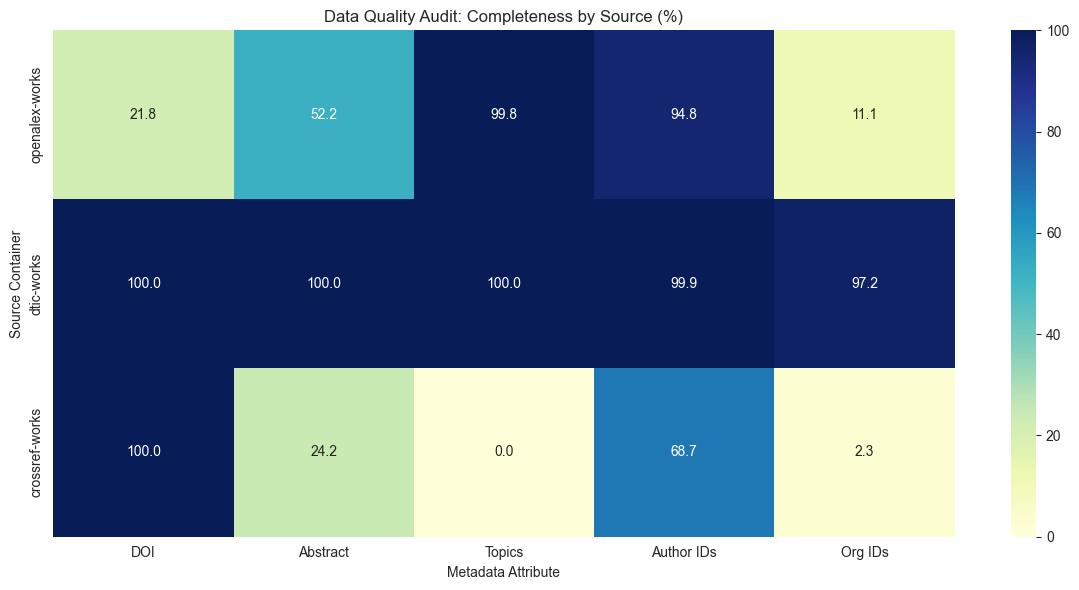


--- Audit Summary Table ---
source_container  total_records  has_doi_pct  has_abstract_pct  has_topics_pct  has_author_ids_pct  has_org_ids_pct
  openalex-works        2992919    21.758157         52.236729       99.823483           94.785191        11.123990
      dtic-works          28071   100.000000        100.000000      100.000000           99.907378        97.214207
  crossref-works        2223875   100.000180         24.153336        0.000000           68.650126         2.348693


In [4]:
all_results = []

# Updated Metrics to handle both OpenAlex/DTIC and Crossref schemas
# We now check for existence AND ensure strings/arrays aren't empty
metrics_to_check = {
    "has_doi": "(IS_DEFINED(c.doi) AND c.doi != '') OR (IS_DEFINED(c.DOI) AND c.DOI != '')",
    
    "has_abstract": "(IS_DEFINED(c.abstract) AND c.abstract != '') OR IS_DEFINED(c.abstract_inverted_index)",
    
    "has_topics": "(IS_DEFINED(c.topics) AND ARRAY_LENGTH(c.topics) > 0) OR "
                  "(IS_DEFINED(c.keywords) AND ARRAY_LENGTH(c.keywords) > 0)",
    
    "has_author_ids": "EXISTS(SELECT VALUE a FROM a IN c.authors WHERE (IS_DEFINED(a.researcher_id) OR IS_DEFINED(a.family))) OR "
                      "EXISTS(SELECT VALUE a FROM a IN c.authorships WHERE IS_DEFINED(a.author.id))",
    
    "has_org_ids": "EXISTS(SELECT VALUE o FROM o IN c.organizations WHERE IS_DEFINED(o.org_id)) OR "
                   "EXISTS(SELECT VALUE a FROM a IN c.authorships WHERE EXISTS(SELECT VALUE i FROM i IN a.institutions WHERE IS_DEFINED(i.id))) OR "
                   "(IS_DEFINED(c.institution_name) AND c.institution_name != '')"
}

for container_name in CONTAINERS_TO_AUDIT:
    print(f"🔍 Auditing {container_name}...")
    container = database.get_container_client(container_name)
    
    # Get Total Count First
    total_res = list(container.query_items("SELECT VALUE COUNT(1) FROM c", enable_cross_partition_query=True))
    total_count = total_res[0] if total_res else 0
    
    if total_count == 0:
        print(f"⚠️ Container {container_name} is empty. Skipping.")
        continue

    container_stats = {'source_container': container_name, 'total_records': total_count}
    
    # Get each metric individually
    for metric_name, condition in metrics_to_check.items():
        query = f"SELECT VALUE COUNT(1) FROM c WHERE {condition}"
        count_res = list(container.query_items(query, enable_cross_partition_query=True))
        container_stats[metric_name] = count_res[0] if count_res else 0
        
    all_results.append(container_stats)

# --- Process and Plot ---
df = pd.DataFrame(all_results)
if not df.empty:
    # Calculate percentages
    for m in metrics_to_check.keys():
        df[f'{m}_pct'] = (df[m] / df['total_records']) * 100

    # Prepare for Plotting
    plot_df = df.set_index('source_container')[[c for c in df.columns if '_pct' in c]]
    
    # Rename columns for the Heatmap labels
    plot_df.columns = ['DOI', 'Abstract', 'Topics', 'Author IDs', 'Org IDs']
    
    # Visualization
    plt.figure(figsize=(12, 6))
    sns.heatmap(plot_df, annot=True, cmap='YlGnBu', fmt=".1f", vmin=0, vmax=100)
    plt.title('Data Quality Audit: Completeness by Source (%)')
    plt.ylabel('Source Container')
    plt.xlabel('Metadata Attribute')
    plt.tight_layout()
    plt.show()
    
    # Print numerical report
    print("\n--- Audit Summary Table ---")
    print(df[['source_container', 'total_records'] + [f'{m}_pct' for m in metrics_to_check.keys()]].to_string(index=False))

Data Processing and Percentage Calculation

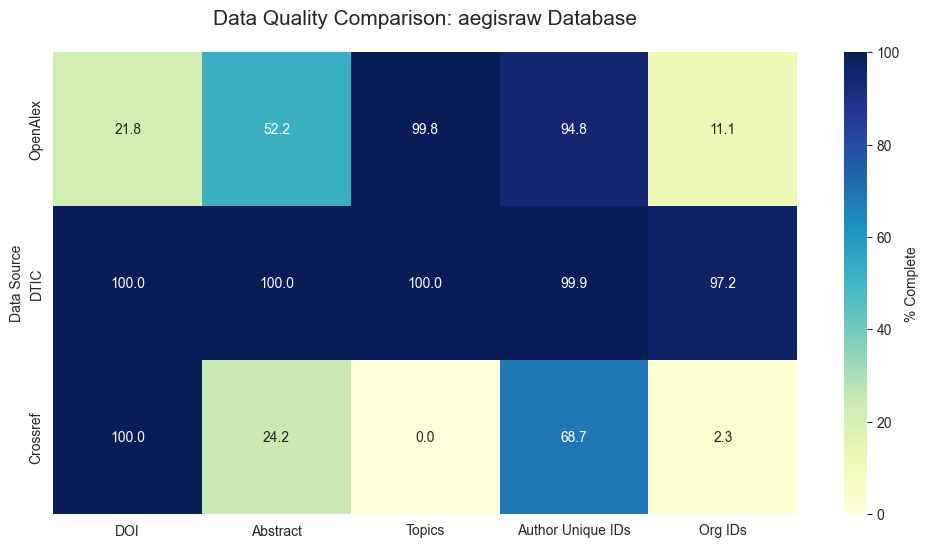

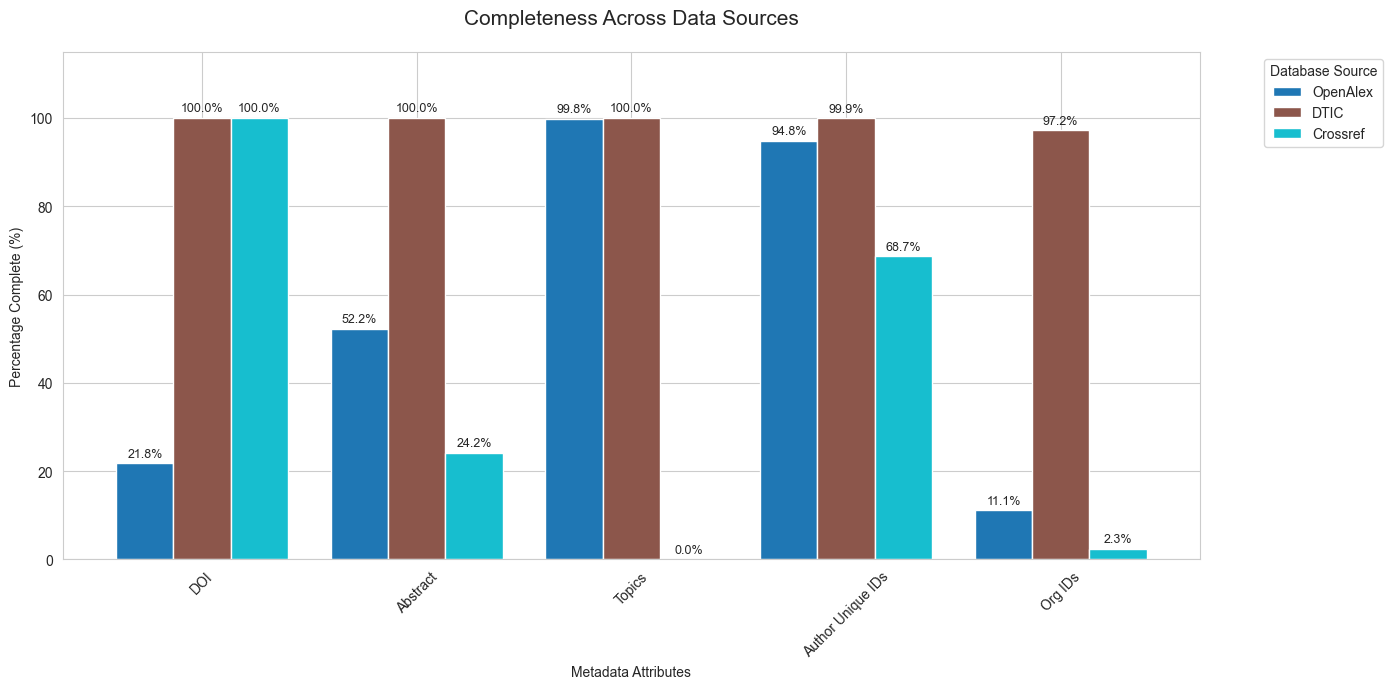


--- Summary Table ---
     Source  total_records  has_doi  has_abstract  has_topics  has_author_ids  \
0  OpenAlex        2992919   651204       1563403     2987636         2836844   
1      DTIC          28071    28071         28071       28071           28045   
2  Crossref        2223875  2223879        537140           0         1526693   

   has_org_ids  
0       332932  
1        27289  
2        52232  


In [5]:
df = pd.DataFrame(all_results)

if not df.empty:
    # 1. Metrics list (matching your updated SQL keys)
    metrics = ['has_doi', 'has_abstract', 'has_topics', 'has_author_ids', 'has_org_ids']
    
    # Calculate percentages for comparison
    for m in metrics:
        if m in df.columns:
            df[f'{m}_pct'] = (df[m] / df['total_records']) * 100
        else:
            df[f'{m}_pct'] = 0.0  # Placeholder if a metric is missing from a container

    # 2. Map source container names to clean labels for the plot
    source_map = {
        'openalex-works': 'OpenAlex', 
        'dtic-works': 'DTIC', 
        'crossref-works': 'Crossref'
    }
    df['Source'] = df['source_container'].replace(source_map)

    # 3. Filter for plotting columns only
    plot_df = df.set_index('Source')[[c for c in df.columns if '_pct' in c]]
    
    # Rename for professional presentation
    plot_df.columns = ['DOI', 'Abstract', 'Topics', 'Author Unique IDs', 'Org IDs']

    # --- 4. VISUALIZATIONS ---
    sns.set_style("whitegrid")
    
    # Heatmap (Visualizing "Fullness")
    plt.figure(figsize=(12, 6))
    sns.heatmap(plot_df, annot=True, cmap='YlGnBu', fmt=".1f", cbar_kws={'label': '% Complete'}, vmin=0, vmax=100)
    plt.title(f'Data Quality Comparison: {DATABASE_NAME} Database', fontsize=15, pad=20)
    plt.ylabel('Data Source')
    plt.show()

    # Bar Chart comparison (Visualizing "The Gap")
    # Using a professional color palette like 'Paired' or 'viridis' for 3+ sources
    ax = plot_df.T.plot(kind='bar', figsize=(14, 7), width=0.8, colormap='tab10')
    plt.title('Completeness Across Data Sources', fontsize=15, pad=20)
    plt.ylabel('Percentage Complete (%)')
    plt.xlabel('Metadata Attributes')
    plt.ylim(0, 115) # Leave room for value labels
    plt.legend(title="Database Source", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)

    # Add data labels on bars for quick reading
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 7), 
                    textcoords='offset points',
                    fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\n--- Summary Table ---")
    # Clean up the output table for console reading
    print(df[['Source', 'total_records'] + metrics])
else:
    print("No data retrieved. Check container names and connectivity.")

The Topic Strength: Almost every record (99.9%) has a topic. OpenAlex uses an AI classifier to tag works, so even if a paper is missing a DOI, it usually still has a topic.

The DOI Gap: Only 43.7% of these records have a DOI. This means over half of the records might be "grey literature," older reports, or datasets that aren't indexed in traditional journals.

The Organization Crisis: Only 8.8% of these records have a persistent Org ID (like a ROR or GRID ID). This is your biggest hurdle.

While there is an abundance of data here, it is very difficult to do "Institutional Analysis" (e.g., "Show me everything from MIT") because the IDs are missing for 90% of the works.

Missing Data Report Per Attribute Per Source

In [6]:
# Create the Final Comparison Report
report_df = pd.DataFrame()

# Updated mapping to include Crossref
source_map = {
    'openalex-works': 'OpenAlex', 
    'dtic-works': 'DTIC', 
    'crossref-works': 'Crossref'
}
report_df['Source'] = df['source_container'].replace(source_map)

# Format total records with commas for high-volume datasets
report_df['Total Records'] = df['total_records'].apply(lambda x: f"{x:,}")

# Logic to calculate missing values
def get_missing(row, key):
    total = row['total_records']
    if total == 0:
        return "0 (0.0%)"
    missing = total - row[key]
    pct = (missing / total) * 100
    return f"{missing:,} ({pct:.1f}%)"

# --- MAPPED TO YOUR RECENT AUDIT RESULTS ---
report_df['DOI Missing'] = df.apply(lambda r: get_missing(r, 'has_doi'), axis=1)
report_df['Topics Missing'] = df.apply(lambda r: get_missing(r, 'has_topics'), axis=1)
report_df['Orgs Missing'] = df.apply(lambda r: get_missing(r, 'has_org_ids'), axis=1) 
report_df['Abstract Missing'] = df.apply(lambda r: get_missing(r, 'has_abstract'), axis=1)
report_df['Author IDs Missing'] = df.apply(lambda r: get_missing(r, 'has_author_ids'), axis=1)

print("--- FINAL DATA QUALITY: MISSING ATTRIBUTE REPORT ---")
# Using display() for Jupyter/IPython or print() for standard terminal
try:
    from IPython.display import display
    display(report_df)
except ImportError:
    print(report_df.to_string(index=False))

# Optional: Export to CSV for Adriana/Team review
# report_df.to_csv(f"data_quality_report_{datetime.now().strftime('%Y%m%d')}.csv", index=False)

--- FINAL DATA QUALITY: MISSING ATTRIBUTE REPORT ---


,Source,Total Records,DOI Missing,Topics Missing,Orgs Missing,Abstract Missing,Author IDs Missing
0,OpenAlex,"2,992,919","2,341,715 (78.2%)","5,283 (0.2%)","2,659,987 (88.9%)","1,429,516 (47.8%)","156,075 (5.2%)"
1,DTIC,"28,071",0 (0.0%),0 (0.0%),782 (2.8%),0 (0.0%),26 (0.1%)
2,Crossref,"2,223,875",-4 (-0.0%),"2,223,875 (100.0%)","2,171,643 (97.7%)","1,686,735 (75.8%)","697,182 (31.3%)"


Missing Data Visualization

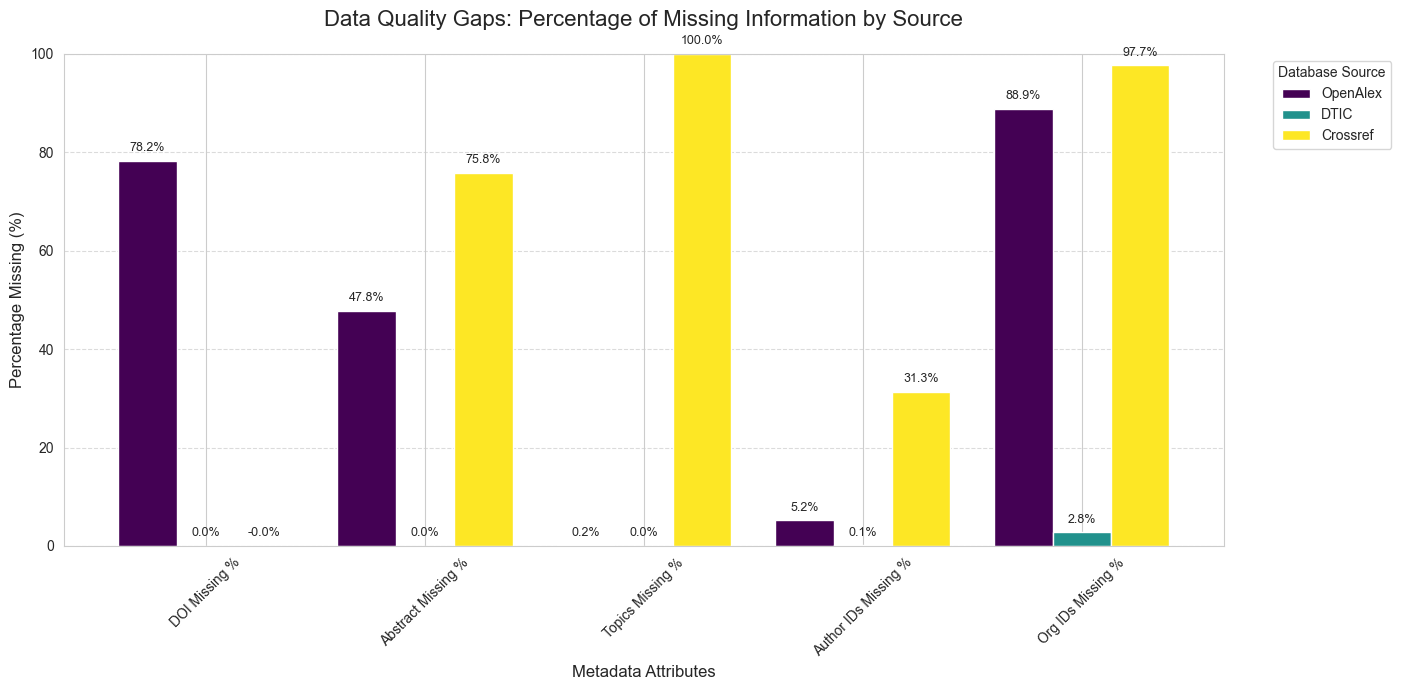

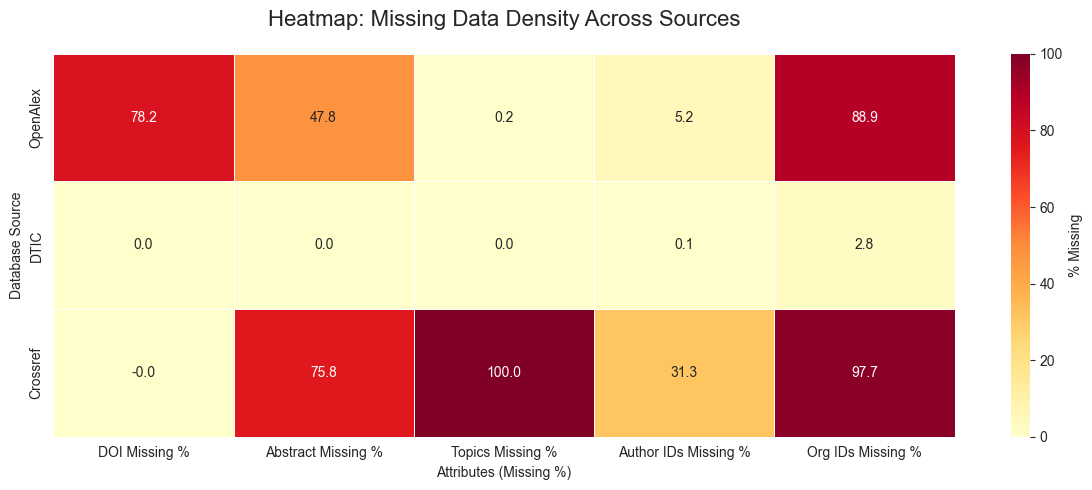

In [7]:
# 1. Prepare the 'Missing' Dataframe for plotting
missing_plot_df = pd.DataFrame()

# Updated mapping to include Crossref
source_map = {
    'openalex-works': 'OpenAlex', 
    'dtic-works': 'DTIC', 
    'crossref-works': 'Crossref'
}
missing_plot_df['Source'] = df['source_container'].replace(source_map)

# Calculate missing percentages for the plot
metrics_map = {
    'has_doi': 'DOI',
    'has_abstract': 'Abstract',
    'has_topics': 'Topics',
    'has_author_ids': 'Author IDs',
    'has_org_ids': 'Org IDs'
}

for raw_col, clean_name in metrics_map.items():
    # Adding a small epsilon or fillna to avoid issues with empty containers
    missing_plot_df[f'{clean_name} Missing %'] = ((df['total_records'] - df[raw_col]) / df['total_records']) * 100

# Set index for plotting
missing_plot_df.set_index('Source', inplace=True)

# --- 2. Visualization A: The Gap Bar Chart ---
sns.set_style("whitegrid")

# Create the plot
# Using a dynamic palette 'muted' or 'Set2' to accommodate 3+ sources automatically
ax = missing_plot_df.T.plot(
    kind='bar', 
    figsize=(14, 7), 
    colormap='viridis', # viridis works well for color-blind accessibility
    width=0.8
)

plt.title('Data Quality Gaps: Percentage of Missing Information by Source', fontsize=16, pad=20)
plt.ylabel('Percentage Missing (%)', fontsize=12)
plt.xlabel('Metadata Attributes', fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.legend(title='Database Source', loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

# --- 3. Visualization B: Heatmap of Data Holes ---
plt.figure(figsize=(12, 5))
# Using 'YlOrRd' (Yellow-Orange-Red) for "Heat" where Red = Bad (Missing)
sns.heatmap(missing_plot_df, annot=True, cmap='YlOrRd', fmt=".1f", linewidths=.5, cbar_kws={'label': '% Missing'})
plt.title('Heatmap: Missing Data Density Across Sources', fontsize=16, pad=20)
plt.ylabel('Database Source')
plt.xlabel('Attributes (Missing %)')
plt.tight_layout()
plt.show()